In [1]:
import joblib
import shap

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
best_model = joblib.load("tuned_xgboost_model.pkl")

print("✅ Tuned XGBoost model loaded successfully.")

✅ Tuned XGBoost model loaded successfully.


## Load Test Data

In [3]:
X_test = joblib.load("X_test.pkl")
y_test = joblib.load("y_test.pkl")

print("X_test Shape :", X_test.shape)
print("y_test Shape :", y_test.shape)

X_test Shape : (3000, 23)
y_test Shape : (3000,)


## Create SHAP Explainer


In [4]:
explainer = shap.TreeExplainer(best_model)

print("✅ SHAP Explainer created successfully.")

✅ SHAP Explainer created successfully.


In [ ]:
shap_values = explainer.shap_values(X_test)
print("SHAP values calculated successfully.")


SHAP values calculated successfully.


array([[ 3.2478388e-04,  1.6815582e-04, -5.4475944e-04, ...,
         6.9018500e-04, -1.7902590e-04, -2.3540065e-03],
       [-5.4760365e-04, -2.9633328e-04,  9.9175703e-04, ...,
        -6.6065247e-04,  4.1751895e-04, -1.1218214e-04],
       [ 3.2478388e-04,  2.2511129e-04, -1.0518462e-03, ...,
        -6.4436853e-04,  4.9379928e-04, -5.7246778e-03],
       ...,
       [ 3.2478388e-04,  7.6073964e-05, -3.1193926e-03, ...,
         6.7007646e-04,  7.2213804e-04, -3.3516646e-03],
       [-5.4760365e-04,  7.6073964e-05, -2.5678345e-03, ...,
        -3.6082435e-03, -4.2211593e-04, -2.1207277e-03],
       [ 3.2478388e-04,  7.6073964e-05,  9.0557738e-04, ...,
        -1.2198577e-03,  4.9861288e-04, -1.1715440e-04]],
      shape=(3000, 23), dtype=float32)

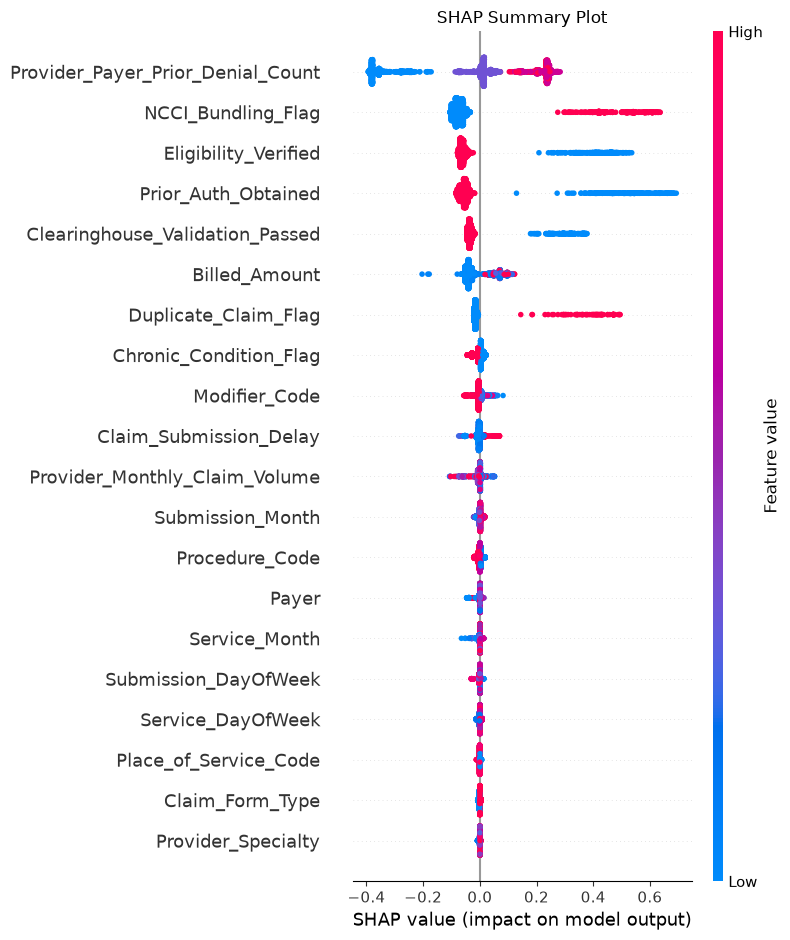

In [8]:
plt.figure(figsize=(12,8))

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.show()

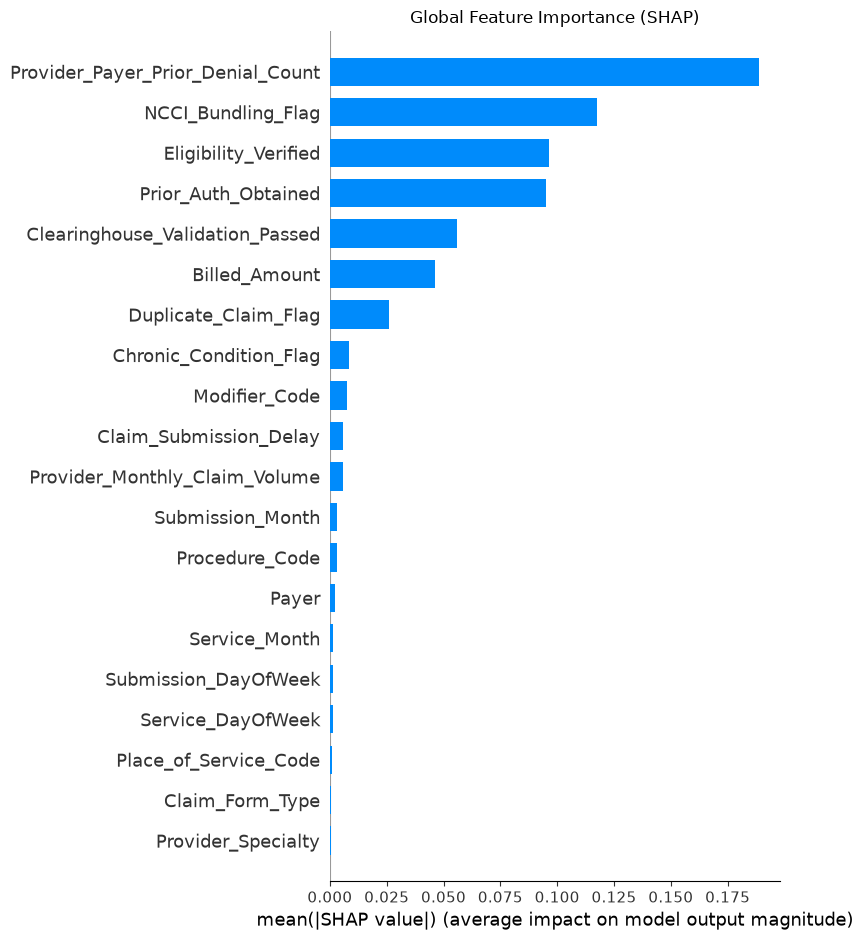

In [9]:
plt.figure(figsize=(10,7))

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.title("Global Feature Importance (SHAP)")
plt.tight_layout()
plt.show()

## Top 10 Important Features

In [10]:
import numpy as np

importance = np.abs(shap_values).mean(axis=0)

feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean_SHAP": importance
})

feature_importance = feature_importance.sort_values(
    by="Mean_SHAP",
    ascending=False
)

feature_importance.head(10)

,Feature,Mean_SHAP
16,Provider_Payer_Prior_Denial_Count,0.188588
13,NCCI_Bundling_Flag,0.117416
11,Eligibility_Verified,0.096257
10,Prior_Auth_Obtained,0.094982
14,Clearinghouse_Validation_Passed,0.056102
7,Billed_Amount,0.046457
12,Duplicate_Claim_Flag,0.026077
17,Chronic_Condition_Flag,0.008535
6,Modifier_Code,0.007326
22,Claim_Submission_Delay,0.005732


## Save SHAP Feature Importance

In [11]:
feature_importance.to_csv(
    "shap_feature_importance.csv",
    index=False
)

print("✅ SHAP Feature Importance saved successfully.")

✅ SHAP Feature Importance saved successfully.


In [12]:
import joblib

joblib.dump(shap_values, "shap_values.pkl")
joblib.dump(explainer, "shap_explainer.pkl")

print("✅ SHAP values saved successfully.")

✅ SHAP values saved successfully.


In [14]:
feature_importance.to_csv(
    "shap_feature_importance.csv",
    index=False
)

print("✅ SHAP Feature Importance saved.")

✅ SHAP Feature Importance saved.


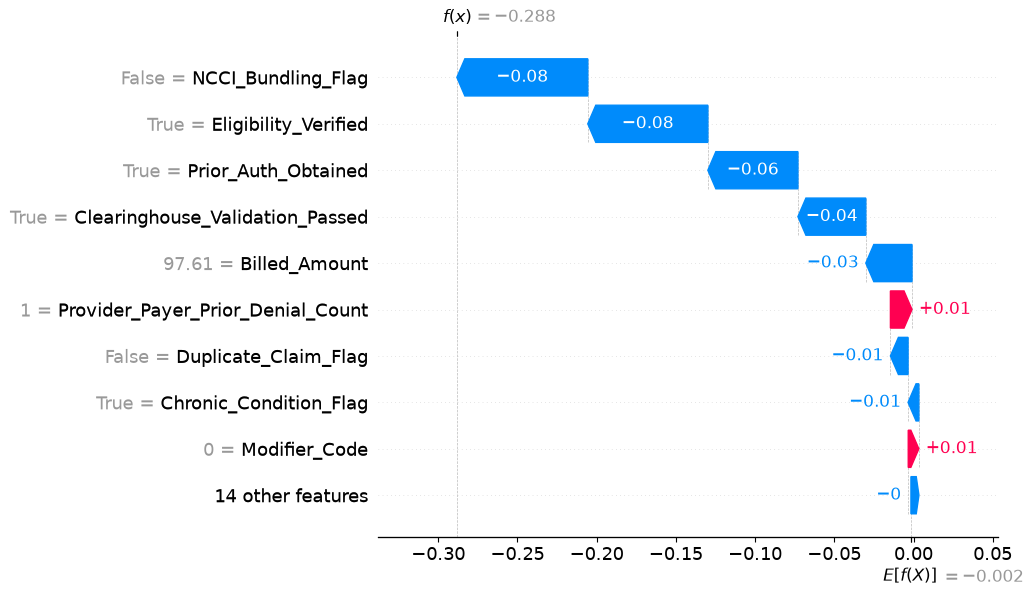

In [16]:
# Select one claim from the test set
claim_index = 0

# Create explanation object
explanation = shap.Explanation(
    values=shap_values[claim_index],
    base_values=explainer.expected_value,
    data=X_test.iloc[claim_index],
    feature_names=X_test.columns
)

# Plot
shap.plots.waterfall(explanation, max_display=10)

In [20]:
print("Prediction Probability:", best_model.predict_proba(X_test.iloc[[claim_index]]))

prediction = best_model.predict(X_test.iloc[[claim_index]])

print("Predicted Class :", prediction[0])

print("Actual Class    :", y_test[claim_index])

Prediction Probability: [[0.57157314 0.42842686]]
Predicted Class : 0
Actual Class    : 0


In [18]:
claim_details = X_test.iloc[[claim_index]]

claim_details.T

,952
Claim_Form_Type,1
Provider_Specialty,5
Payer,5
Place_of_Service_Code,11
Diagnosis_Code,11
Procedure_Code,93000
Modifier_Code,0
Billed_Amount,97.61
Payer_Timely_Filing_Limit_Days,365
Prior_Auth_Required,False


In [19]:
shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[claim_index],
    X_test.iloc[claim_index]
)

In [22]:
joblib.dump(explainer, "shap_explainer.pkl")
joblib.dump(shap_values, "shap_values.pkl")

print("SHAP objects saved successfully.")

SHAP objects saved successfully.
